In [34]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
X = np.array([
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7]
])

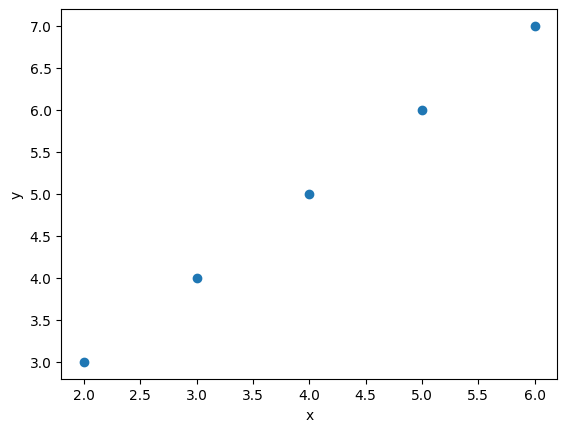

In [35]:
plt.scatter(X[:,0], X[:,1])
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [36]:
X_centered = X - np.mean(X, axis=0)

cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
principal = eigenvectors[:, np.argmax(eigenvalues)]

X_reduced = X_centered @ principal

print(X_reduced)

[-2.82842712 -1.41421356  0.          1.41421356  2.82842712]


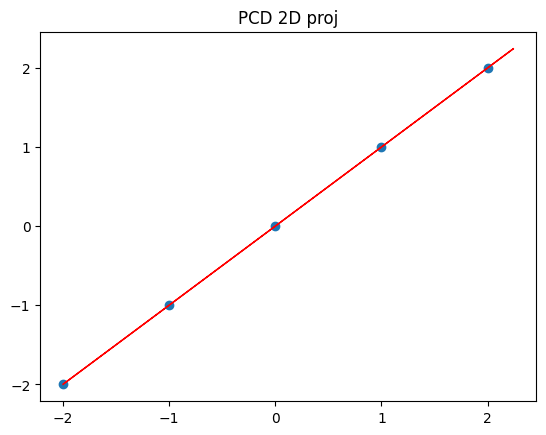

In [37]:
plt.scatter(X_centered[:,0], X_centered[:,1])

vector = principal * 6

plt.arrow(-2,-2, vector[0], vector[1], color="red")

plt.title("PCD 2D proj")
plt.show()

In [38]:
np.random.seed(0)

n = 50

class1 = np.random.rand(n,3) + np.array([2,2,2])
class2 = np.random.uniform([5,4,3], [7,6,5], (n,3))
# class2 = np.random.uniform([5,0,3], [8,10,4], (n,3))
class3 = np.random.multivariate_normal([3,7,6], np.eye(3)*0.5, n)

# class1 = np.random.rand(n,3) + np.array([4,2,0])
# class2 = np.random.uniform([6,4,3], [7,6,5], (n,3))
# class3 = np.random.multivariate_normal([3,7,7], np.eye(3)*0.5, n)
X = np.vstack((class1, class2, class3))

labels = np.array(
    ["A"]*n +
    ["B"]*n +
    ["C"]*n
)

In [39]:
theta = 0

In [40]:
R = np.array([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0, 0, 1]
])
X = X @ R

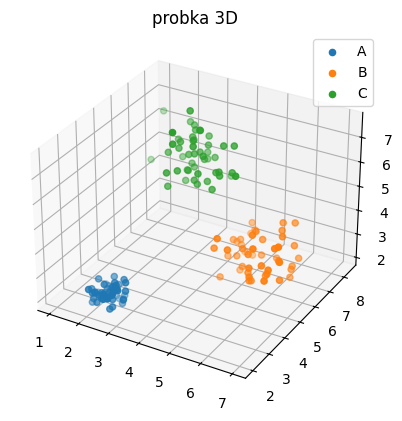

In [41]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for label in np.unique(labels):

    idx = labels == label

    ax.scatter(
        X[idx,0],
        X[idx,1],
        X[idx,2],
        label=label
    )

ax.set_title("probka 3D")
ax.legend()

plt.show()

In [42]:
X_centered = X - np.mean(X, axis=0)
cov = np.cov(X_centered.T)

eigenvalues, eigenvectors = np.linalg.eig(cov)
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

W = eigenvectors[:, :2]

X_reduced = X_centered @ W

PCA znajduje nowe osie danych (principal components),
które maksymalizują wariancję.
Macierz kowariancji -> opis zależności między wymiarami

Wektory własne -> nowe osie przestrzeni

Rzutujemy dane na pierwsze dwa komponenty,
otrzymując reprezentację 2D.

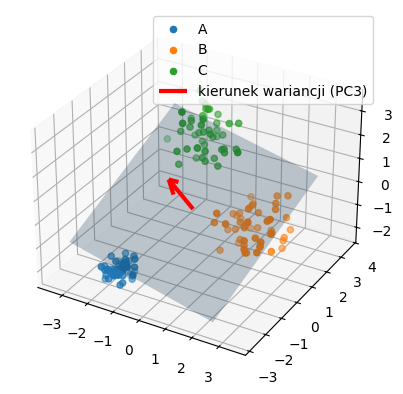

In [43]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for label in np.unique(labels):

    idx = labels == label

    ax.scatter(
        X_centered[idx,0],
        X_centered[idx,1],
        X_centered[idx,2],
        label=label
    )

u = np.linspace(-3,3,5)
v = np.linspace(-3,3,5)

U,V = np.meshgrid(u,v)

plane = np.outer(U.flatten(), W[:,0]) + np.outer(V.flatten(), W[:,1])

X_plane = plane[:,0].reshape(U.shape)
Y_plane = plane[:,1].reshape(U.shape)
Z_plane = plane[:,2].reshape(U.shape)

ax.plot_surface(
    X_plane,
    Y_plane,
    Z_plane,
    alpha=0.25
)
# pc3 prostopadły do płaszczyzny

normal_vector = eigenvectors[:,2]

ax.quiver(
    0,0,0,
    normal_vector[0] * 3,
    normal_vector[1] * 3,
    normal_vector[2] * 3,
    linewidth=3,
    color='red',
    label="kierunek wariancji (PC3)"
)
ax.legend()

plt.show()

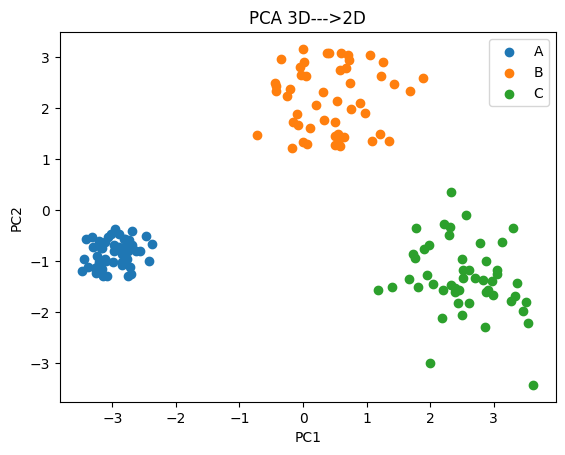

In [44]:
plt.figure()

for label in np.unique(labels):

    idx = labels == label

    plt.scatter(
        X_reduced[idx,0],
        X_reduced[idx,1],
        label=label
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 3D--->2D")

plt.legend()

plt.show()

In [45]:
#pierwszy komponent PCA
W1 = eigenvectors[:, :1]
X_reduced_1D = X_centered @ W1

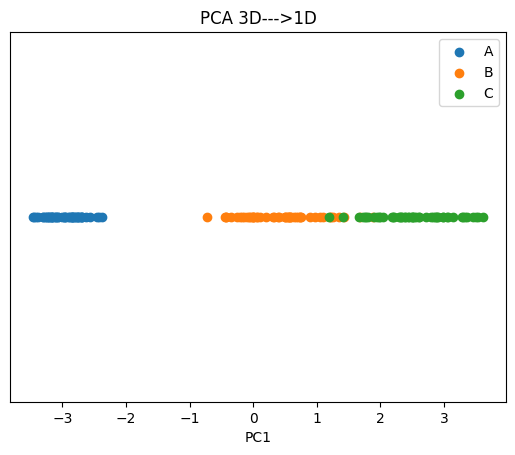

In [46]:
plt.figure()

for label in np.unique(labels):

    idx = labels == label

    plt.scatter(
        X_reduced_1D[idx,0],
        np.zeros(np.sum(idx)),
        label=label
    )

plt.xlabel("PC1")
plt.yticks([])

plt.title("PCA 3D--->1D")
plt.legend()

plt.show()

vector quantization (klastry)

In [47]:
from sklearn.cluster import KMeans

# liczba centroidów = "wymiar"
k = 2   # odpowiednik 2D (bardzo uproszczone)

kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(X)

centroids = kmeans.cluster_centers_
labels_vq = kmeans.labels_

# rekonstrukcja (każdy punkt → centroid)
X_vq = centroids[labels_vq]

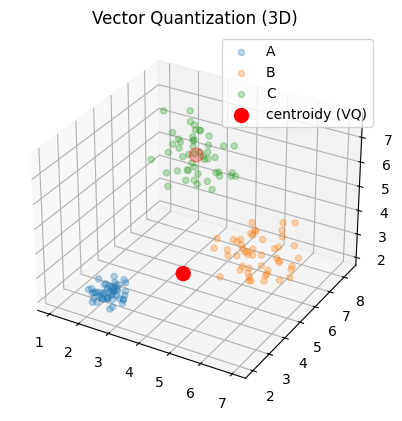

In [48]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for label in np.unique(labels):

    idx = labels == label

    ax.scatter(
        X[idx,0],
        X[idx,1],
        X[idx,2],
        label=label,
        alpha=0.3
    )

# centroidy (ważne!)
ax.scatter(
    centroids[:,0],
    centroids[:,1],
    centroids[:,2],
    color='red',
    s=100,
    label="centroidy (VQ)"
)

ax.set_title("Vector Quantization (3D)")
ax.legend()

plt.show()

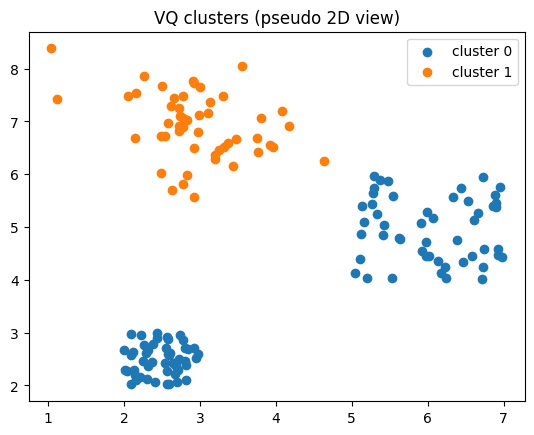

In [49]:
plt.figure()

for i in range(k):

    idx = labels_vq == i

    plt.scatter(
        X[idx,0],
        X[idx,1],
        label=f"cluster {i}"
    )

plt.title("VQ clusters (pseudo 2D view)")
plt.legend()
plt.show()

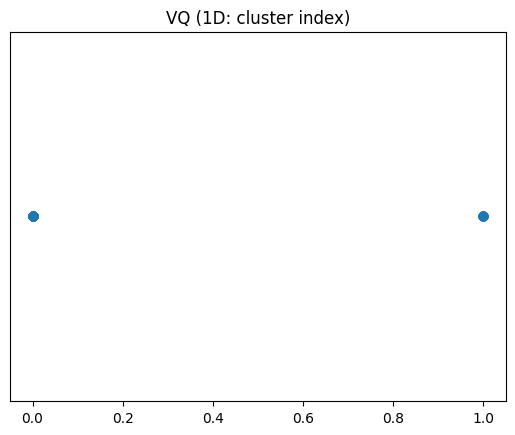

In [50]:
plt.figure()

plt.scatter(labels_vq, np.zeros_like(labels_vq))

plt.title("VQ (1D: cluster index)")
plt.yticks([])

plt.show()